In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
os.chdir("/mnt/datadisk/lizhongzhan/SpaMultiOmics/Benchmark/datatset/MultiOmics/Mouse_embryo_unpaired")

In [3]:
atac_annot = pd.read_csv("GSE214986_metadata_embryo_satac.csv.gz", sep=";", index_col=0)

In [4]:
atac = sc.read_h5ad("atac.h5ad")
atac.obs_names = [i+"_5" for i in atac.obs_names]

In [5]:
atac_annot = atac_annot[atac_annot["age"]=="e12.5"]
atac_annot

,nCount_peaks,nFeature_peaks,nCount_RNA,nFeature_RNA,total,duplicate,chimeric,unmapped,lowmapq,mitochondrial,...,peak_region_fragments,peak_region_cutsites,y,x,pixel_y,pixel_x,section,sample,age,clusters
AAACAAGGGATCAAAT-1_5,3408,3271,7802,5277,85789,47769,216,658,11105,10947,...,944,1713,32,72,8425,32857,220403_C2,5,e12.5,Hindbrain
AAACAGCAGTCTGCTA-1_5,1165,1139,2434,2132,24827,12449,56,247,3443,4557,...,411,744,47,33,6475,34162,220403_C2,5,e12.5,Liver
AAACATTCGGGATTCT-1_5,1771,1702,3843,3106,41603,20615,186,471,6141,7430,...,588,1051,47,23,5975,34162,220403_C2,5,e12.5,Liver
AAACCTGGCACACCCT-1_5,2674,2584,6662,4680,71997,42389,176,623,9155,5540,...,733,1344,22,34,6525,31987,220403_C2,5,e12.5,Internal
AAACGCGGCGAAAGTA-1_5,469,461,1640,1356,31622,17082,22,167,8585,623,...,124,236,39,91,9375,33466,220403_C2,5,e12.5,Meningeal_PNS_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGACTATTTGGG-1_6,1386,1360,3404,2786,39305,21848,131,468,5664,4138,...,430,794,39,79,8775,33466,220403_D2,6,e12.5,Muscle_heart
TTGTTGGAAGGCGGCA-1_6,615,610,1351,1232,15557,8545,50,193,2051,1959,...,170,313,67,95,9575,35902,220403_D2,6,e12.5,Hindbrain
TTGTTGTGCCCTTGAA-1_6,1032,1016,3126,2414,58690,32386,113,508,11454,3672,...,258,482,48,10,5325,34249,220403_D2,6,e12.5,Meningeal_PNS_1
TTGTTGTGGAGACAGT-1_6,659,646,1464,1324,19986,8398,126,350,3301,5136,...,254,465,64,38,6725,35641,220403_D2,6,e12.5,Liver


In [6]:
common_names = sorted(list(set(atac.obs_names) & set(atac_annot.index)))

In [7]:
atac = atac[common_names]
atac.obs["cell_type"] = atac_annot.loc[common_names, "clusters"]
sx = atac_annot.loc[common_names, "y"]
sy = atac_annot.loc[common_names, "x"]
atac.obsm["spatial"] = np.vstack([sx, sy]).T

In [16]:
annot

,X,nCount_peaks,nFeature_peaks,nCount_RNA,nFeature_RNA,total,duplicate,chimeric,unmapped,lowmapq,...,section,sample,age,clusters,leiden,anno_type,anno_type_refined,new_id,info,cell_type
E12_S1#AAACAAGGGATCAAAT-1,AAACAAGGGATCAAAT-1,3408,3271,7802,5277,85789,47769,216,658,11105,...,220403_C2,5,e12.5,Hindbrain,2,Facial_bone,Facial_bone,E12_S1,e12.5_5,Chondrocyte prog.2
E12_S1#AAACAGCAGTCTGCTA-1,AAACAGCAGTCTGCTA-1,1165,1139,2434,2132,24827,12449,56,247,3443,...,220403_C2,5,e12.5,Liver,7,Liver,Liver,E12_S1,e12.5_5,Primitive erythroid lineage
E12_S1#AAACATTCGGGATTCT-1,AAACATTCGGGATTCT-1,1771,1702,3843,3106,41603,20615,186,471,6141,...,220403_C2,5,e12.5,Liver,7,Liver,Liver,E12_S1,e12.5_5,Primitive erythroid lineage
E12_S1#AAACCTGGCACACCCT-1,AAACCTGGCACACCCT-1,2674,2584,6662,4680,71997,42389,176,623,9155,...,220403_C2,5,e12.5,Internal,1,Muscle_heart,Muscle_heart,E12_S1,e12.5_5,Chondrocyte prog.2
E12_S1#AAACGCGGCGAAAGTA-1,AAACGCGGCGAAAGTA-1,469,461,1640,1356,31622,17082,22,167,8585,...,220403_C2,5,e12.5,Meningeal_PNS_2,9,Periventricular,Periventricular,E12_S1,e12.5_5,Postmitotic neurons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E15_S1#TTGTTCCTTCTCCAAT-1,TTGTTCCTTCTCCAAT-1,1662,1618,3444,2797,19389,8552,83,139,2208,...,220327_A1,1,e15.5,Hindbrain,2,Facial_bone,Facial_bone,E15_S1,e15.5_1,Facial mesenchyme
E15_S1#TTGTTGACTATTTGGG-1,TTGTTGACTATTTGGG-1,2816,2684,5387,3999,30047,12587,71,274,3615,...,220327_A1,1,e15.5,Midbrain,5,PNS1,Meningeal_PNS_1,E15_S1,e15.5_1,Cholinergic neurons
E15_S1#TTGTTGTGCCCTTGAA-1,TTGTTGTGCCCTTGAA-1,1660,1619,3738,3010,23716,10090,60,197,3372,...,220327_A1,1,e15.5,Muscle_heart,7,Facial_bone,Facial_bone,E15_S1,e15.5_1,Undefined
E15_S1#TTGTTGTGGAGACAGT-1,TTGTTGTGGAGACAGT-1,1183,1148,2290,1968,12491,5187,50,114,1557,...,220327_A1,1,e15.5,Muscle_heart,3,Muscle_heart,Muscle_heart,E15_S1,e15.5_1,Facial mesenchyme


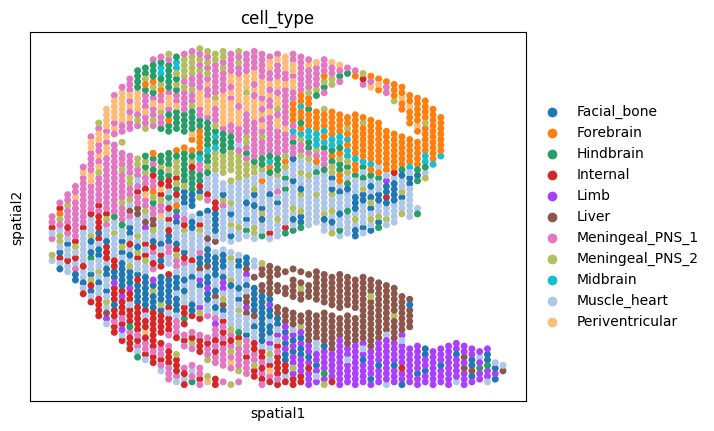

In [8]:
sc.pl.embedding(atac, basis="spatial", color="cell_type", size=100)

In [196]:
# atac.write("e12_atac.h5ad")

In [ ]:
sc.pp.normalize_total(atac)
sc.pp.log1p(atac)
sc.pp.pca(atac)
sc.pp.neighbors(atac)

In [185]:
sc.tl.leiden(atac, resolution=2.0)

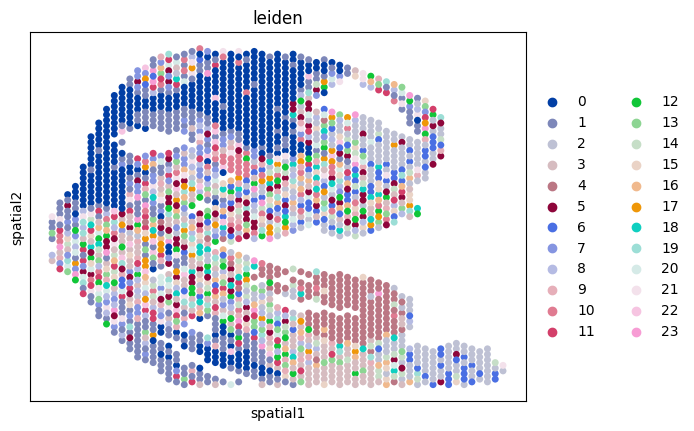

In [186]:
sc.pl.embedding(atac, basis="spatial", color="leiden", size=100)


In [197]:
rna = sc.read_10x_h5("GSE214989_counts_embryo_visium.h5")
rna_annot = pd.read_csv("GSE214989_metadata_embryo_visium.csv.gz", sep=";", index_col=0)
rna_annot = rna_annot.loc[rna.obs_names]
rna.obs["cluster"] = list(rna_annot["seurat_clusters_harmony"].astype(str))

In [198]:
e12_spatial = pd.read_csv("GSM6619680_220420_sATAC_V10B01-031_B1_tissue_positions_list.csv", index_col=0, header=None)
e12_spatial.columns = ["in_tissue", "x", "y", "px", "py"]
e12_spatial.index = [i+"_3" for i in e12_spatial.index]

In [199]:
common_names = sorted(list(set(e12_spatial.index) & set(rna.obs_names)))

In [200]:
rna = rna[common_names,]
e12_spatial = e12_spatial.loc[common_names,]

In [201]:
rna.obsm["spatial"] = np.array(e12_spatial[["x", "y"]])
rna.obsm["spatial"][:,1] = rna.obsm["spatial"][:,1] * -1
rna.obsm["spatial"][:,0] = rna.obsm["spatial"][:,0] * -1

In [202]:
# sc.pp.normalize_total(rna)
# sc.pp.log1p(rna)
# sc.pp.pca(rna)
# sc.pp.neighbors(rna)
# sc.tl.leiden(rna, resolution=0.6)

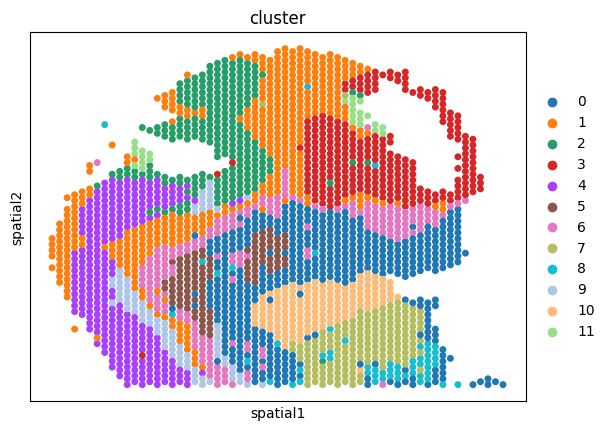

In [203]:
sc.pl.embedding(rna, basis="spatial", size=100, color="cluster")

In [205]:
rna.write("e12_rna.h5ad")

In [204]:
# rna.obs["cell_type"] = rna.obs["cluster"].map({
#     "2": "Hindbrain",
#     "3": "Forebrain",
#     "7": "Liver"
#     "10": "Heart",
# })